In [11]:
import pandas as pd

df = pd.read_csv("../data/loan_data.csv")
df.head()


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


In [12]:
df.columns

Index(['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term',
       'Employment_Status', 'Loan_Approved'],
      dtype='str')

In [13]:
df['Loan_Approved'].value_counts(dropna=False)

Loan_Approved
0    1658
1     342
Name: count, dtype: int64

In [14]:
df = df.dropna(subset=['Loan_Approved'])

In [15]:
df['Loan_Approved'].isnull().sum()

np.int64(0)

In [16]:
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.915

In [17]:
y_prob = model.predict_proba(X_test)
y_prob[:5]

array([[9.99589200e-01, 4.10799785e-04],
       [9.74051909e-01, 2.59480914e-02],
       [4.63285431e-01, 5.36714569e-01],
       [5.06013857e-01, 4.93986143e-01],
       [6.63711249e-01, 3.36288751e-01]])

In [19]:
import numpy as np

confidence_scores = np.max(y_prob, axis=1)
confidence_scores[:10]

array([0.9995892 , 0.97405191, 0.53671457, 0.50601386, 0.66371125,
       0.99970161, 0.9932842 , 0.9907687 , 0.99999341, 0.99649067])

In [20]:
HIGH_CONF = 0.80
MEDIUM_CONF = 0.60

In [21]:
def confidence_level(conf):
    if conf >= HIGH_CONF:
        return "HIGH"
    elif conf >= MEDIUM_CONF:
        return "MEDIUM"
    else:
        return "LOW"

In [22]:
confidence_labels = [confidence_level(c) for c in confidence_scores]
confidence_labels[:10]

['HIGH',
 'HIGH',
 'LOW',
 'LOW',
 'MEDIUM',
 'HIGH',
 'HIGH',
 'HIGH',
 'HIGH',
 'HIGH']

In [23]:
import pandas as pd

conf_df = pd.DataFrame({
    "true_label": y_test.values,
    "predicted_label": model.predict(X_test),
    "confidence": confidence_scores,
    "confidence_level": confidence_labels
})

conf_df.head(10)

,true_label,predicted_label,confidence,confidence_level
0,0,0,0.999589,HIGH
1,0,0,0.974052,HIGH
2,1,1,0.536715,LOW
3,1,0,0.506014,LOW
4,1,0,0.663711,MEDIUM
5,0,0,0.999702,HIGH
6,0,0,0.993284,HIGH
7,0,0,0.990769,HIGH
8,0,0,0.999993,HIGH
9,0,0,0.996491,HIGH


In [24]:
conf_df['confidence_level'].value_counts()

confidence_level
HIGH      352
MEDIUM     29
LOW        19
Name: count, dtype: int64

In [25]:
conf_df.groupby("confidence_level")["true_label"].mean()

confidence_level
HIGH      0.139205
LOW       0.736842
MEDIUM    0.517241
Name: true_label, dtype: float64

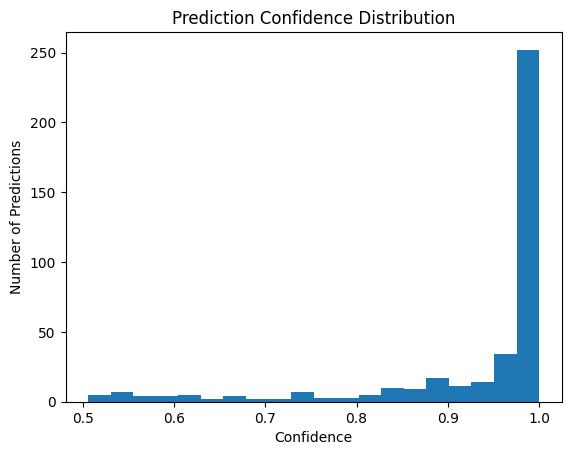

In [26]:
import matplotlib.pyplot as plt

plt.hist(confidence_scores, bins=20)
plt.xlabel("Confidence")
plt.ylabel("Number of Predictions")
plt.title("Prediction Confidence Distribution")
plt.show()

In [27]:
reference_data = X_train.copy()
current_data = X_test.copy()

In [40]:
import pandas as pd

drift_stats = []

for col in reference_data.columns:
    ref_mean = reference_data[col].mean()
    cur_mean = current_data[col].mean()
    
    ref_std = reference_data[col].std()
    cur_std = current_data[col].std()
    
    mean_diff = abs(ref_mean - cur_mean)
    
    drift_stats.append({
        "feature": col,
        "ref_mean": ref_mean,
        "cur_mean": cur_mean,
        "mean_diff": mean_diff,
        "ref_std": ref_std,
        "cur_std": cur_std
    })

drift_df = pd.DataFrame(drift_stats)
drift_df.head()

,feature,ref_mean,cur_mean,mean_diff,ref_std,cur_std
0,Age,43.610000,44.5875,0.977500,14.891071,15.074164
1,Income,84476.443750,84762.1500,285.706250,37800.641135,37699.414071
2,Credit_Score,576.863750,577.8200,0.956250,157.135761,159.273091
3,Loan_Amount,25507.779375,25270.4575,237.321875,14058.914059,14361.953307
4,Loan_Term,35.317500,36.1200,0.802500,16.826204,17.617080


In [41]:
drift_df["drift_detected"] = drift_df["mean_diff"] > (0.5 * drift_df["ref_std"])

In [42]:
drift_df.sort_values("mean_diff", ascending=False).head(10)

,feature,ref_mean,cur_mean,mean_diff,ref_std,cur_std,drift_detected
1,Income,84476.443750,84762.1500,285.706250,37800.641135,37699.414071,False
3,Loan_Amount,25507.779375,25270.4575,237.321875,14058.914059,14361.953307,False
0,Age,43.610000,44.5875,0.977500,14.891071,15.074164,False
2,Credit_Score,576.863750,577.8200,0.956250,157.135761,159.273091,False
4,Loan_Term,35.317500,36.1200,0.802500,16.826204,17.617080,False
5,Employment_Status_Self-Employed,0.180625,0.1900,0.009375,0.384827,0.392792,False
6,Employment_Status_Unemployed,0.188125,0.1850,0.003125,0.390934,0.388784,False


In [43]:
drift_df["drift_detected"].value_counts()

drift_detected
False    7
Name: count, dtype: int64

In [44]:
def trust_decision(confidence, drift_detected):
    if confidence >= 0.80 and not drift_detected:
        return "AUTO_APPROVE"
    elif confidence >= 0.60:
        return "REVIEW_REQUIRED"
    else:
        return "DO_NOT_TRUST"

In [45]:
conf_df["trust_decision"] = conf_df["confidence"].apply(
    lambda c: trust_decision(c, drift_detected=False)
)

conf_df.head(10)

,true_label,predicted_label,confidence,confidence_level,trust_decision
0,0,0,0.999589,HIGH,AUTO_APPROVE
1,0,0,0.974052,HIGH,AUTO_APPROVE
2,1,1,0.536715,LOW,DO_NOT_TRUST
3,1,0,0.506014,LOW,DO_NOT_TRUST
4,1,0,0.663711,MEDIUM,REVIEW_REQUIRED
5,0,0,0.999702,HIGH,AUTO_APPROVE
6,0,0,0.993284,HIGH,AUTO_APPROVE
7,0,0,0.990769,HIGH,AUTO_APPROVE
8,0,0,0.999993,HIGH,AUTO_APPROVE
9,0,0,0.996491,HIGH,AUTO_APPROVE


In [46]:
conf_df["trust_decision"].value_counts()

trust_decision
AUTO_APPROVE       352
REVIEW_REQUIRED     29
DO_NOT_TRUST        19
Name: count, dtype: int64